# **Dataset**

In [1]:
# load dataset
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
drug_reviews_druglib_com = fetch_ucirepo(id=461)

# data (as pandas dataframes)
X = drug_reviews_druglib_com.data.features

# metadata
print(drug_reviews_druglib_com.metadata)

# variable information
print(drug_reviews_druglib_com.variables)


{'uci_id': 461, 'name': 'Drug Reviews (Druglib.com)', 'repository_url': 'https://archive.ics.uci.edu/dataset/461/drug+review+dataset+druglib+com', 'data_url': 'https://archive.ics.uci.edu/static/public/461/data.csv', 'abstract': 'The dataset provides patient reviews on specific drugs along with related conditions. Reviews and ratings are grouped into reports on the three aspects benefits, side effects and overall comment.', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate', 'Text'], 'num_instances': 4143, 'num_features': 8, 'feature_types': ['Integer'], 'demographics': [], 'target_col': None, 'index_col': ['reviewID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Wed Apr 03 2024', 'dataset_doi': '10.24432/C55G6J', 'creators': ['Surya Kallumadi', 'Felix Grer'], 'intro_paper': {'ID': 457, 'type': 'NATIVE', 'title': 'Aspect-Based Sentiment Analysis of D

# **Preprocessing**
From the dataset, we can have:
*   `benefitsReview` → Benefit aspect
*   `sideEffectsReview` → Side Effects aspect
*   `commentsReview` → General/Overall aspect

Also:
*   `effectiveness` (categorical: Highly Effective, Marginally Effective, etc.) → sentiment label for benefits
*   `sideEffects` (categorical: Severe, Mild, None) → sentiment label for side effects

In [3]:
# Clean Reviews
import unicodedata, re

def basic_clean(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKC", s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)                       # collapse spaces
    s = re.sub(r"(.)\1{2,}", r"\1\1\1", s)           # cooool -> coool
    s = re.sub(r"http\S+|www\.\S+", "<url>", s)      # URLs
    s = re.sub(r"@\w+", "<user>", s)                 # handles
    s = re.sub(r"\b\d+(\.\d+)?\b", "<num>", s)       # numbers -> <num>
    # keep ! ? ' for negation/sentiment
    return s

In [4]:
from collections import Counter
import numpy as np

def class_stats(y, labels=None, name=""):
    cnt = Counter(y)
    n = sum(cnt.values())
    labels = labels or sorted(cnt.keys())
    print(f"[{name}] N={n} | " + " | ".join(f"{c}:{cnt[c]} ({cnt[c]/n:.1%})" for c in labels))
    # weights: inverse-frequency normalized to mean=1
    freqs = np.array([cnt[c] for c in labels], dtype=float)
    w = (freqs.mean() / freqs)
    return {c: float(w[i]) for i, c in enumerate(labels)}

In [ ]:
# Map numeric ratings → sentiment (neg, neu, pos)
#def map_rating(r):
#    if r <= 4: return "negative"
#    elif r <= 6: return "neutral"
#    else: return "positive"

#X['sentiment'] = X['rating'].apply(map_rating)

## comments recall for NEUTRAL ~ 0.03 so wide the band for neutral(4~7)

In [7]:
print("Value counts for sideEffects:")
print(X['sideEffects'].value_counts())

print("\nValue counts for effectiveness:")
print(X['effectiveness'].value_counts())

Value counts for sideEffects:
sideEffects
Mild Side Effects                1349
No Side Effects                  1198
Moderate Side Effects             850
Severe Side Effects               491
Extremely Severe Side Effects     255
Name: count, dtype: int64

Value counts for effectiveness:
effectiveness
Highly Effective          1741
Considerably Effective    1238
Moderately Effective       572
Ineffective                329
Marginally Effective       263
Name: count, dtype: int64


In [5]:
# Map numeric ratings → sentiment (neg, neu, pos)
# second try
def map_rating(r):
    if r <= 3:    return "negative"
    elif r <= 7:  return "neutral"
    elif r <= 10: return "positive"
    else: return None

X['sentiment'] = X['rating'].apply(map_rating)

In [6]:
# simple mapping (USED)
def map_side_effects(val):
    if "No Side Effects" in val:                  return "positive"
    elif "Mild Side Effects" in val:              return "neutral"
    elif "Moderate Side Effects" in val:          return "negative"
    elif "Severe Side Effects" in val:            return "negative"
    elif "Extremely Severe Side Effects" in val:  return "negative"
    else: return None

X['side_sentiment'] = X['sideEffects'].apply(map_side_effects)

In [ ]:
# detailed mapping
def map_side_effects(val):
    if re.search(r"\bno side effect(s)?\b", val, re.IGNORECASE):    return "positive"
    if re.search(r"\bmild\b", val, re.IGNORECASE):                  return "neutral"
    if re.search(r"\bmoderate\b", val, re.IGNORECASE):              return "neutral"
    if re.search(r"\bsevere|serious|intense\b", val, re.IGNORECASE):return "negative"
    if re.search(r"\bextremely severe\b", val, re.IGNORECASE):      return "negative"
    # alternates
    if re.search(r"\bnone?\b", val, re.IGNORECASE):                 return "positive"
    if re.search(r"\bno\b", val, re.IGNORECASE) and "effect" in val.lower():  return "positive"
    return None

X['side_sentiment'] = X['sideEffects'].apply(map_side_effects)

In [7]:
# simple mapping (USED)
def map_effectiveness(val):
    if "Highly Effective" in val:           return "positive"
    elif "Considerably Effective" in val:   return "positive"
    elif "Moderately Effective" in val:     return "neutral"
    elif "Marginally Effective" in val:     return "neutral"
    elif "Ineffective" in val:              return "negative"
    else: return None

X['benefit_sentiment'] = X['effectiveness'].apply(map_effectiveness)

In [ ]:
# detailed mapping - no difference
def map_effectiveness(val):
    if re.search(r"\b(high(ly)?|very)\s+effective\b", val, re.IGNORECASE):      return "positive"
    if re.search(r"\bconsiderably\s+effective\b", val, re.IGNORECASE):          return "positive"
    if re.search(r"\bmoderate(ly)?\s+effective\b", val, re.IGNORECASE):         return "neutral"
    if re.search(r"\bmarginal(ly)?\s+effective\b", val, re.IGNORECASE):         return "negative"
    if re.search(r"\bineffective|not\s+effective\b", val, re.IGNORECASE):       return "negative"
    # fully matching simple tags
    if re.fullmatch(r"\beffective\b", val, re.IGNORECASE):                      return "positive"
    if re.fullmatch(r"\bpartially effective\b", val, re.IGNORECASE):            return "neutral"
    return None

X['benefit_sentiment'] = X['effectiveness'].apply(map_effectiveness)

In [8]:
df = X.copy()

df['comments_clean'] = df['commentsReview'].apply(basic_clean)
df['benefits_clean'] = df['benefitsReview'].apply(basic_clean)
df['side_clean']     = df['sideEffectsReview'].apply(basic_clean)


df['label_comments'] = df['rating'].apply(map_rating)
df['label_benefits'] = df['effectiveness'].apply(map_effectiveness)
df['label_side']     = df['sideEffects'].apply(map_side_effects)

df = df.dropna(subset=['comments_clean','benefits_clean','side_clean',
                       'label_comments','label_benefits','label_side']).reset_index(drop=True)


In [12]:
# 1) Did mapping drop anything?
print("side_sentiment NaN:", df['label_side'].isna().sum())
print("benefit_sentiment NaN:", df['label_comments'].isna().sum())

# 2) How many rows have each text column?
for col in ['comments_clean','benefits_clean','side_clean']:
    print(col, df[col].notna().sum())

# 3) How many rows survive if you require ALL THREE texts + BOTH labels?
mask_all = (
    df['comments_clean'].notna() &
    df['benefits_clean'].notna() &
    df['side_clean'].notna() &
    df['label_comments'].notna() &
    df['label_side'].notna()
)
print("Rows with ALL aspects present:", mask_all.sum())

side_sentiment NaN: 0
benefit_sentiment NaN: 0
comments_clean 4143
benefits_clean 4143
side_clean 4143
Rows with ALL aspects present: 4143


# **Train Models**
(A) Baselines (TF-IDF + ML)

*   Preprocess text per aspect
*   Extract features with `TfidfVectorizer`
*   Train classifiers: SVM, SVC, XGBoost

In [24]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

from sklearn.svm import LinearSVC, SVC
from sklearn.multiclass import OneVsRestClassifier

from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [10]:
# Expect columns in your df
ASPECTS: Dict[str, Dict[str, str]] = {
    "Comments":  {"text": "comments_clean",  "label": "label_comments"},
    "Benefits":  {"text": "benefits_clean",  "label": "label_benefits"},
    "SideEffects":   {"text": "side_clean",  "label": "label_side"},
}

In [11]:
DEFAULT_MODELS = ["SVM","SVC","XGBoost"]

In [12]:
def _safe_array(x):
    if isinstance(x, (pd.Series, pd.Index)):
        return x.to_numpy()
    if isinstance(x, list):
        return np.asarray(x)
    return x

In [13]:
def _fit_label_encoder(y_str: np.ndarray):
    le = LabelEncoder()
    y_enc = le.fit_transform(y_str)
    return le, y_enc

In [14]:
def _effective_n_splits(y: np.ndarray, desired_splits: int) -> int:
    _, counts = np.unique(y, return_counts=True)
    max_allowed = counts.min()
    return max(2, min(desired_splits, int(max_allowed)))

In [15]:
def _build_pipeline(model_name: str, n_classes: int):
    """
    Build (pipeline, param_grid) with step name 'clf'.
    """
    tfidf = TfidfVectorizer(max_features=30000,
                            ngram_range=(1, 3),
                            analyzer="word",
                            sublinear_tf=True)

    if model_name == "SVM":
        clf = OneVsRestClassifier(LinearSVC(class_weight="balanced", random_state=42))
        pipe = Pipeline([("tfidf", tfidf), ("clf", clf)])
        param_grid = {
            "clf__estimator__C": [0.1, 1.0, 10.0],
        }

    elif model_name == "SVC":
        clf = OneVsRestClassifier(SVC(kernel="rbf",
                                      class_weight="balanced",
                                      probability=True,
                                      random_state=42))
        pipe = Pipeline([("tfidf", tfidf), ("clf", clf)])
        param_grid = {
            "clf__estimator__C": [1.0, 4.0],
            "clf__estimator__gamma": ["scale", 0.1],
        }

    elif model_name == "XGBoost":
        clf = XGBClassifier(
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            tree_method="hist",
            max_depth=6, learning_rate=0.1, n_estimators=400,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            n_jobs=-1, random_state=42,
        )
        pipe = Pipeline([("tfidf", tfidf), ("clf", clf)])
        param_grid = {
            "clf__max_depth": [4, 6],
            "clf__learning_rate": [0.05, 0.1],
            "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0],
            "clf__min_child_weight": [1, 3],
        }

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return pipe, param_grid

In [28]:
@dataclass
class FoldResult:
    fold_idx: int
    best_params: Dict[str, Any]
    macro_f1: float
    accuracy: float
    y_true: np.ndarray = None
    y_pred: np.ndarray = None
    confmat: np.ndarray = None

@dataclass
class AspectResult:
    aspect: str
    model: str
    n_samples: int
    labels: List[str]
    folds: List[FoldResult]

    @property
    def macro_f1_mean(self) -> float:
        return float(np.mean([f.macro_f1 for f in self.folds])) if self.folds else np.nan

    @property
    def macro_f1_std(self) -> float:
        return float(np.std([f.macro_f1 for f in self.folds])) if self.folds else np.nan

    @property
    def acc_mean(self) -> float:
        return float(np.mean([f.accuracy for f in self.folds])) if self.folds else np.nan

    @property
    def acc_std(self) -> float:
        return float(np.std([f.accuracy for f in self.folds])) if self.folds else np.nan


In [25]:
def nested_cv_for_aspect(
    texts: np.ndarray,
    y_str: np.ndarray,
    model_name: str,
    outer_splits: int = 5,
    inner_splits: int = 3,
    random_state: int = 42,
) -> Tuple[AspectResult, LabelEncoder]:
    """
    Nested cross-validation for one aspect.
    Stores y_true, y_pred, and confusion matrix per fold.
    """
    texts = _safe_array(texts).astype(str)
    y_str = _safe_array(y_str).astype(str)

    le = LabelEncoder()
    y = le.fit_transform(y_str)
    n_classes = len(le.classes_)

    outer_k = _effective_n_splits(y, outer_splits)
    inner_k = _effective_n_splits(y, inner_splits)

    pipe, param_grid = _build_pipeline(model_name, n_classes)

    outer_cv = StratifiedKFold(n_splits=outer_k, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=inner_k, shuffle=True, random_state=random_state)

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=0,
        error_score="raise",
    )

    fold_results: List[FoldResult] = []

    for fidx, (tr, te) in enumerate(outer_cv.split(texts, y), start=1):
        gs.fit(texts[tr], y[tr])
        y_pred = gs.predict(texts[te])

        macro_f1 = f1_score(y[te], y_pred, average="macro")
        acc = accuracy_score(y[te], y_pred)
        cm = confusion_matrix(y[te], y_pred, labels=list(range(n_classes)))  # ✅ now defined

        fold_results.append(FoldResult(
            fold_idx=fidx,
            best_params=gs.best_params_,
            macro_f1=macro_f1,
            accuracy=acc,
            y_true=y[te],
            y_pred=y_pred,
            confmat=cm
        ))

        print(f"[{model_name}] Fold {fidx}/{outer_k} — macro-F1: {macro_f1:.4f} | acc: {acc:.4f} | best: {gs.best_params_}")

    ar = AspectResult(
        aspect="",  # filled in later by run_all_aspects
        model=model_name,
        n_samples=len(texts),
        labels=list(le.classes_),
        folds=fold_results,
    )
    return ar, le

In [26]:
def run_all_aspects(
    df: pd.DataFrame,
    aspects: Dict[str, Dict[str, str]] = ASPECTS,
    models_to_run: List[str] = DEFAULT_MODELS,
    min_rows: int = 50
):
    """
    Runs nested CV for each requested model on each aspect (dict config).
    Returns nested dict: results[aspect][model] -> AspectResult
    """
    results: Dict[str, Dict[str, AspectResult]] = {}

    for aspect, cfg in aspects.items():
        text_col = cfg["text"]
        label_col = cfg["label"]

        sub = df[[text_col, label_col]].dropna().reset_index(drop=True)
        texts = sub[text_col].astype(str).to_numpy()
        y_str = sub[label_col].astype(str).to_numpy()

        print("\n" + "=" * 28, f"{aspect.upper()}", "=" * 28)
        print(f"N = {len(sub)} | labels: {sorted(list(pd.Series(y_str).unique()))}")

        if len(sub) < min_rows:
            print(f"Skipping (too few rows < {min_rows}).")
            continue

        results[aspect] = {}

        for model_name in models_to_run:
            print(f"\n===== {model_name} =====")
            try:
                ar, _ = nested_cv_for_aspect(texts, y_str, model_name=model_name)
                ar.aspect = aspect
                results[aspect][model_name] = ar

                print("-" * 72)
                print(f"{aspect} — {model_name}:")
                print(f"macro-F1: {ar.macro_f1_mean:.4f} | "
                      f"acc: {ar.acc_mean:.4f}")
                print(f"labels: {ar.labels}")
            except Exception as e:
                print("-" * 72)
                print(f"{aspect} — {model_name} FAILED with error:\n{e}")

    return results


# **Evaluation Metrics**
*   Micro/Macro F1 → balanced performance measure
*   Hamming Loss → fraction of wrong labels per sample
*   Subset Accuracy → exact match across all aspects
*   Latency (p95 < 150ms) → time per inference (useful for DistilBERT real-time claim)

Baseline - SVM & XGBoost

In [19]:
from sklearn.metrics import f1_score, hamming_loss, accuracy_score
import time, numpy as np
from sklearn.metrics import classification_report

In [29]:
results_svm = run_all_aspects(df, ASPECTS, models_to_run=["SVM"])


============================ COMMENTS ============================
N = 4143 | labels: ['negative', 'neutral', 'positive']

===== SVM =====
[SVM] Fold 1/5 — macro-F1: 0.5033 | acc: 0.5694 | best: {'clf__estimator__C': 0.1}
[SVM] Fold 2/5 — macro-F1: 0.5008 | acc: 0.5682 | best: {'clf__estimator__C': 0.1}
[SVM] Fold 3/5 — macro-F1: 0.5006 | acc: 0.5669 | best: {'clf__estimator__C': 0.1}
[SVM] Fold 4/5 — macro-F1: 0.4931 | acc: 0.5616 | best: {'clf__estimator__C': 0.1}
[SVM] Fold 5/5 — macro-F1: 0.5042 | acc: 0.5761 | best: {'clf__estimator__C': 0.1}
------------------------------------------------------------------------
Comments — SVM:
macro-F1: 0.5004 | acc: 0.5684
labels: [np.str_('negative'), np.str_('neutral'), np.str_('positive')]

============================ BENEFITS ============================
N = 4143 | labels: ['negative', 'neutral', 'positive']

===== SVM =====
[SVM] Fold 1/5 — macro-F1: 0.6260 | acc: 0.7515 | best: {'clf__estimator__C': 0.1}
[SVM] Fold 2/5 — macro-F1: 0.62

In [46]:
results_svc = run_all_aspects(df, ASPECTS, models_to_run=["SVC"])


============================ COMMENTS ============================
N = 4143 | labels: ['negative', 'neutral', 'positive']

===== SVC =====
[SVC] Fold 1/5 — macro-F1: 0.5044 | acc: 0.5706 | best: {'clf__estimator__C': 4.0, 'clf__estimator__gamma': 0.1}
[SVC] Fold 2/5 — macro-F1: 0.5165 | acc: 0.5862 | best: {'clf__estimator__C': 4.0, 'clf__estimator__gamma': 0.1}
[SVC] Fold 3/5 — macro-F1: 0.4841 | acc: 0.5585 | best: {'clf__estimator__C': 4.0, 'clf__estimator__gamma': 0.1}
[SVC] Fold 4/5 — macro-F1: 0.4847 | acc: 0.5700 | best: {'clf__estimator__C': 4.0, 'clf__estimator__gamma': 0.1}
[SVC] Fold 5/5 — macro-F1: 0.5109 | acc: 0.5845 | best: {'clf__estimator__C': 4.0, 'clf__estimator__gamma': 0.1}
------------------------------------------------------------------------
Comments — SVC:
macro-F1: 0.5001 | acc: 0.5740
labels: [np.str_('negative'), np.str_('neutral'), np.str_('positive')]

============================ BENEFITS ============================
N = 4143 | labels: ['negative', 'neu

In [49]:
results_xgb = run_all_aspects(df, ASPECTS, models_to_run=["XGBoost"])


============================ COMMENTS ============================
N = 4143 | labels: ['negative', 'neutral', 'positive']

===== XGBoost =====
[XGBoost] Fold 1/5 — macro-F1: 0.4219 | acc: 0.5645 | best: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__min_child_weight': 3, 'clf__subsample': 1.0}
[XGBoost] Fold 2/5 — macro-F1: 0.4549 | acc: 0.5814 | best: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__subsample': 0.8}
[XGBoost] Fold 3/5 — macro-F1: 0.4227 | acc: 0.5597 | best: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__min_child_weight': 1, 'clf__subsample': 0.8}
[XGBoost] Fold 4/5 — macro-F1: 0.4234 | acc: 0.5652 | best: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__min_child_weight': 3, 'clf__subsample': 0.8}
[XGBoost] Fold 5/5 — macro-F1: 0.4320 | acc: 0.5870 | best: {'clf__colsample_bytree': 1.0, 'clf_

# **Visualization**

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

In [31]:
def _get_fold_cm(fr, n_labels):
    if getattr(fr, "confmat", None) is not None:
        return fr.confmat
    if getattr(fr, "y_true", None) is not None and getattr(fr, "y_pred", None) is not None:
        return confusion_matrix(fr.y_true, fr.y_pred, labels=list(range(n_labels)))
    return None

In [32]:
def _plot_confmat(cm, labels, title, normalize=False):
    disp = cm.copy()
    fmt = "d"
    if normalize:
        row_sums = disp.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        disp = disp / row_sums
        fmt = ".2f"

    plt.figure(figsize=(5,4))
    sns.heatmap(disp, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [59]:
def show_confmats_only(results_dict, normalize=False):
    """
    Display aggregated confusion matrices for each aspect-model pair.
    """
    for aspect, models in results_dict.items():
        for model, ar in models.items():
            cms = []
            for fr in ar.folds:
                cm = _get_fold_cm(fr, n_labels=len(ar.labels))
                if cm is not None:
                    cms.append(cm)
            if not cms:
                print(f"No confusion matrices found for {aspect} — {model}")
                continue
            cm_sum = np.sum(cms, axis=0)
            title = f"{aspect} - Confusion Matrix ({model}) "
            _plot_confmat(cm_sum, ar.labels, title, normalize=normalize)

In [57]:
def summarize_results(results_dict, model_name="Model") -> pd.DataFrame:
    """
    Print & return table of Mean Accuracy and Mean Macro-F1 by aspect and model,
    and plot a grouped bar chart.
    """
    rows = []
    for aspect, models in results_dict.items():
        for model, ar in models.items():
            rows.append({
                "Aspect": aspect,
                "Model": model,
                "Mean Accuracy": round(ar.acc_mean, 4),
                "Mean Macro-F1": round(ar.macro_f1_mean, 4)
            })
    df_summary = pd.DataFrame(rows)

    if df_summary.empty:
        print("⚠️ No results found — run your models first.")
        return df_summary

    # === Print table ===
    print("\n=== Mean Accuracy and Macro-F1 by Aspect ===")
    print(df_summary.to_string(index=False))

    # === Bar Chart ===
    plt.figure(figsize=(7,5))
    x = np.arange(len(df_summary["Aspect"]))
    bar_width = 0.35

    plt.bar(x - bar_width/2, df_summary["Mean Accuracy"], width=bar_width, label="Accuracy")
    plt.bar(x + bar_width/2, df_summary["Mean Macro-F1"], width=bar_width, label="Macro-F1", color="darkblue")

    plt.xticks(x, df_summary["Aspect"])
    plt.ylabel("Score")
    plt.ylim(0, 1.0)
    plt.title(f"Mean Accuracy & Macro-F1 by Aspect ({model})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df_summary

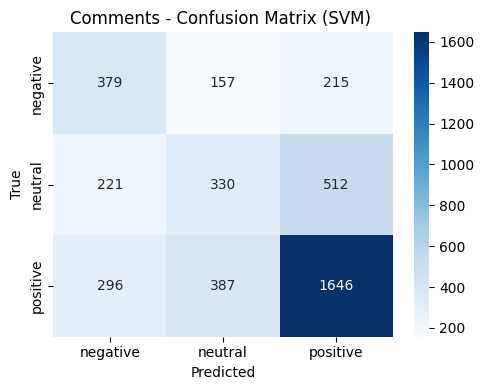

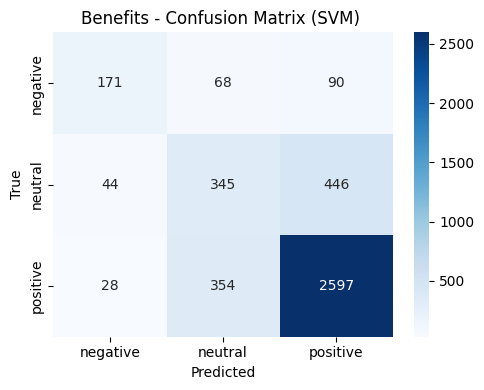

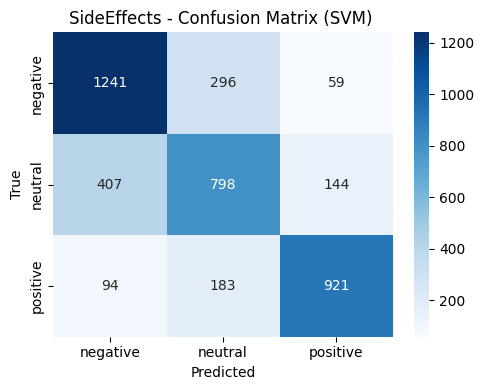

In [60]:
show_confmats_only(results_svm)


=== Mean Accuracy and Macro-F1 by Aspect ===
     Aspect Model  Mean Accuracy  Mean Macro-F1
   Comments   SVM         0.5684         0.5004
   Benefits   SVM         0.7514         0.6254
SideEffects   SVM         0.7145         0.7148


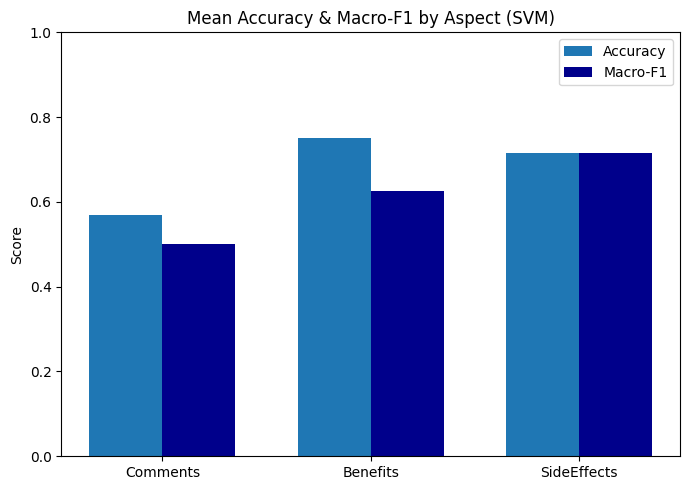

In [54]:
_ = summarize_results(results_svm)

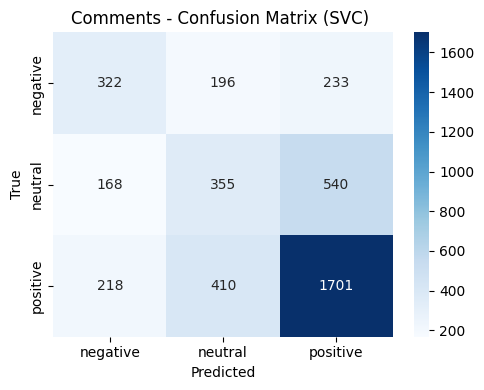

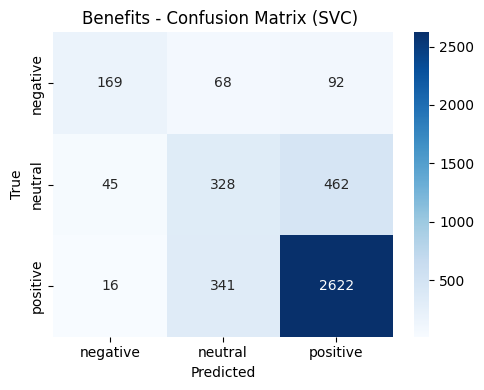

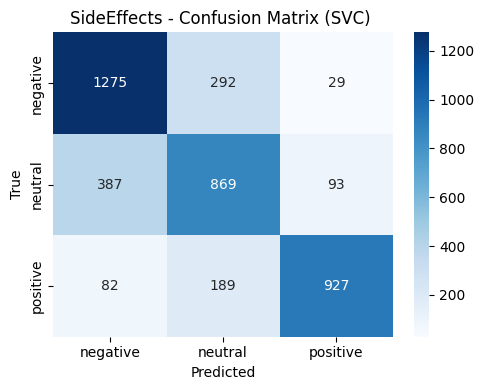

In [61]:
show_confmats_only(results_svc)


=== Mean Accuracy and Macro-F1 by Aspect ===
     Aspect Model  Mean Accuracy  Mean Macro-F1
   Comments   SVC         0.5740         0.5001
   Benefits   SVC         0.7528         0.6240
SideEffects   SVC         0.7412         0.7441


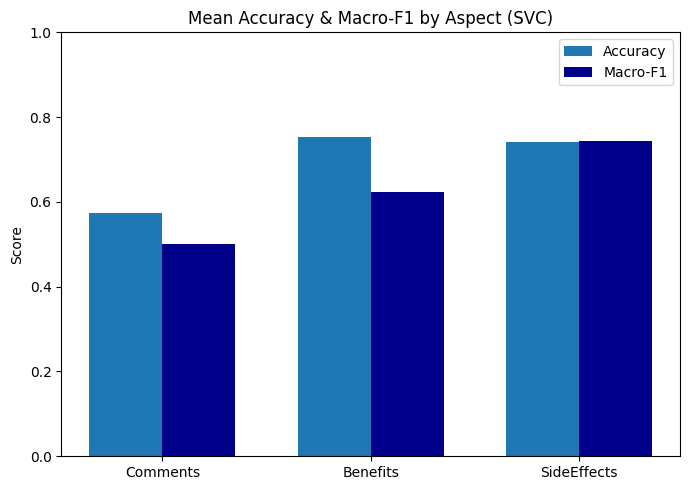

In [62]:
_ = summarize_results(results_svc)

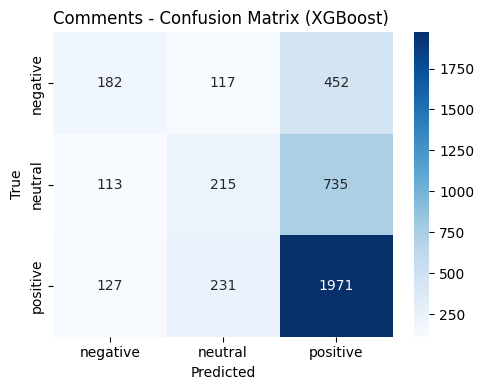

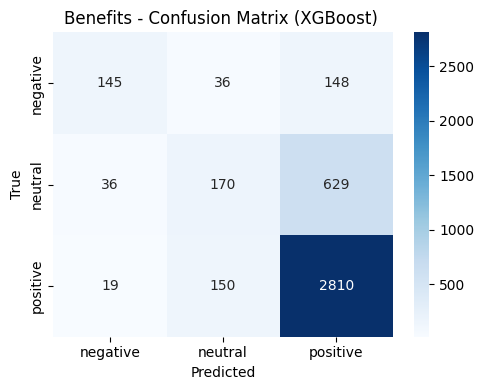

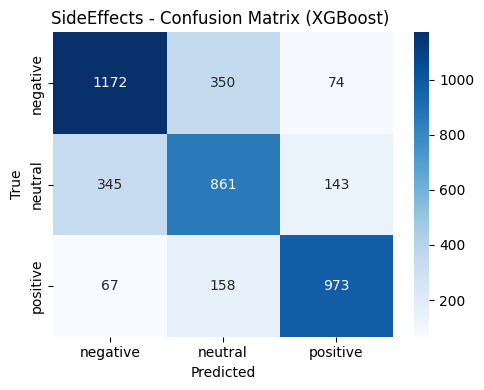

In [63]:
show_confmats_only(results_xgb)


=== Mean Accuracy and Macro-F1 by Aspect ===
     Aspect   Model  Mean Accuracy  Mean Macro-F1
   Comments XGBoost         0.5716         0.4310
   Benefits XGBoost         0.7543         0.5629
SideEffects XGBoost         0.7256         0.7284


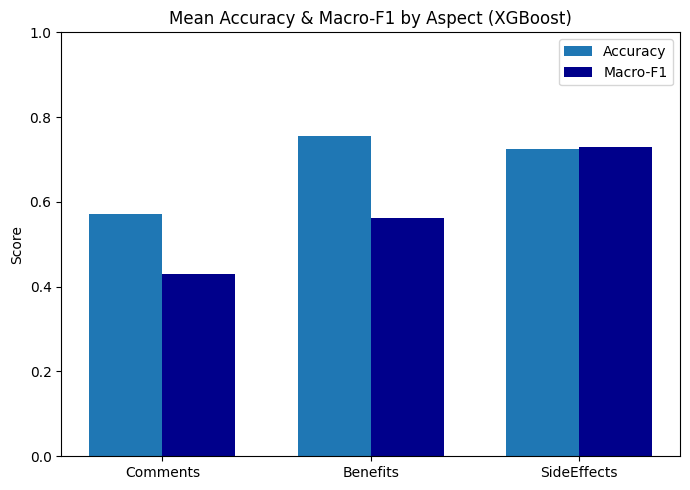

In [64]:
_ = summarize_results(results_xgb)

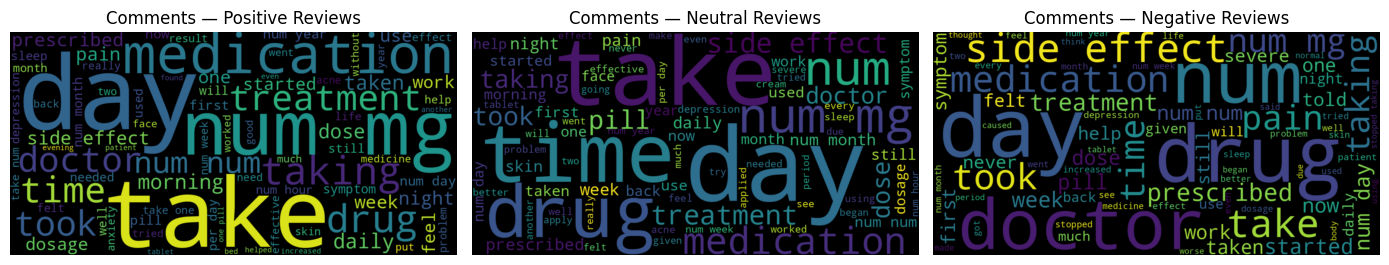

In [70]:
!pip install wordcloud
from wordcloud import WordCloud

def plot_wordcloud_by_sentiment(df, text_col, label_col, aspect_name):
    sentiments = ["positive","neutral","negative"]
    fig, axes = plt.subplots(1, 3, figsize=(14,4))
    for i, sent in enumerate(sentiments):
        text = " ".join(df.loc[df[label_col] == sent, text_col].astype(str))
        wc = WordCloud(width=1200, height=600, max_words=80, colormap="viridis").generate(text)
        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].set_title(f"{aspect_name} — {sent.title()} Reviews")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

plot_wordcloud_by_sentiment(df, "comments_clean", "label_comments", "Comments")


In [71]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

def plot_roc_curve(model, X_test, y_test, class_labels):
    y_bin = label_binarize(y_test, classes=class_labels)
    y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Macro-average ROC Curve — SVC (RBF)")
    plt.legend(loc="lower right")
    plt.show()


Top 10 indicative terms for Comments:
                term      chi2
7319         stopped  7.999601
6984             she  7.869076
8012        the side  7.789215
5253           never  7.474819
5261      never take  7.264751
7324  stopped taking  7.228073
9280    was supposed  6.907436
6588        reaction  6.831513
9144             was  6.516249
6252      pharmacist  6.351250


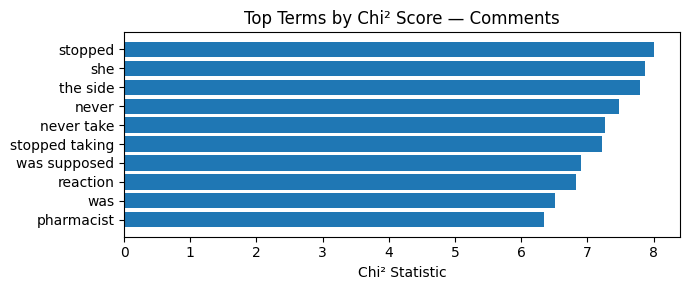

In [72]:
from sklearn.feature_selection import chi2
import numpy as np
import pandas as pd

def chi2_top_terms(df, text_col, label_col, aspect_name, n=10):
    from sklearn.feature_extraction.text import TfidfVectorizer
    vec = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    X = vec.fit_transform(df[text_col])
    y = df[label_col]
    chi2_scores, p = chi2(X, y)
    terms = np.array(vec.get_feature_names_out())
    top = pd.DataFrame({"term": terms, "chi2": chi2_scores}).sort_values("chi2", ascending=False).head(n)
    print(f"\nTop {n} indicative terms for {aspect_name}:")
    print(top)
    plt.figure(figsize=(7,3))
    plt.barh(top.term[::-1], top.chi2[::-1])
    plt.title(f"Top Terms by Chi² Score — {aspect_name}")
    plt.xlabel("Chi² Statistic")
    plt.tight_layout()
    plt.show()

chi2_top_terms(df, "comments_clean", "label_comments", "Comments")

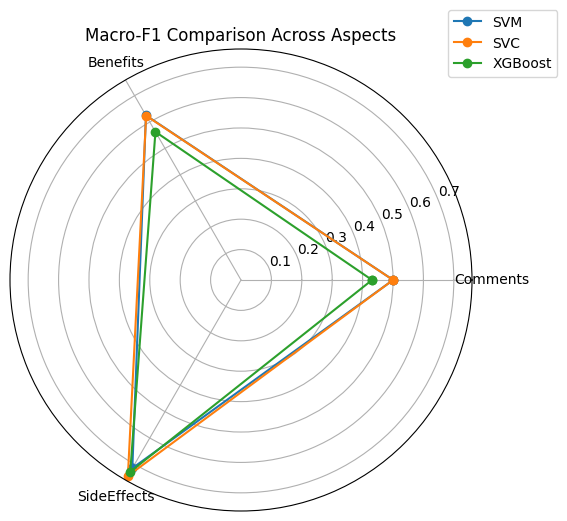

In [73]:
from math import pi

# mean summary by model (across all aspects)
summary = pd.DataFrame([
    ["SVM", results_svm["Comments"]["SVM"].macro_f1_mean, results_svm["Benefits"]["SVM"].macro_f1_mean, results_svm["SideEffects"]["SVM"].macro_f1_mean],
    ["SVC", results_svc["Comments"]["SVC"].macro_f1_mean, results_svc["Benefits"]["SVC"].macro_f1_mean, results_svc["SideEffects"]["SVC"].macro_f1_mean],
    ["XGBoost", results_xgb["Comments"]["XGBoost"].macro_f1_mean, results_xgb["Benefits"]["XGBoost"].macro_f1_mean, results_xgb["SideEffects"]["XGBoost"].macro_f1_mean],
], columns=["Model","Comments","Benefits","SideEffects"])

# Radar plot
categories = ["Comments","Benefits","SideEffects"]
N = len(categories)

plt.figure(figsize=(6,6))
for i, row in summary.iterrows():
    values = row[categories].tolist()
    values += values[:1]  # close circle
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    plt.polar(angles, values, marker="o", label=row["Model"])
plt.xticks([n / float(N) * 2 * np.pi for n in range(N)], categories)
plt.title("Macro-F1 Comparison Across Aspects")
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.show()


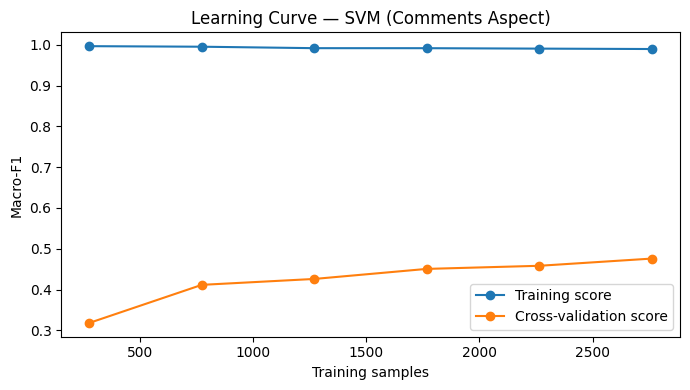

In [74]:
from sklearn.model_selection import learning_curve
import numpy as np

# Example: SVM on Comments
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

pipe = make_pipeline(
    TfidfVectorizer(max_features=30000, ngram_range=(1,2), sublinear_tf=True),
    LinearSVC(class_weight="balanced", random_state=42)
)

X = df["comments_clean"]
y = df["label_comments"]

train_sizes, train_scores, test_scores = learning_curve(pipe, X, y,
    cv=3, scoring="f1_macro", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6), random_state=42)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,4))
plt.plot(train_sizes, train_mean, "o-", label="Training score")
plt.plot(train_sizes, test_mean, "o-", label="Cross-validation score")
plt.xlabel("Training samples"); plt.ylabel("Macro-F1")
plt.title("Learning Curve — SVM (Comments Aspect)")
plt.legend(); plt.tight_layout(); plt.show()


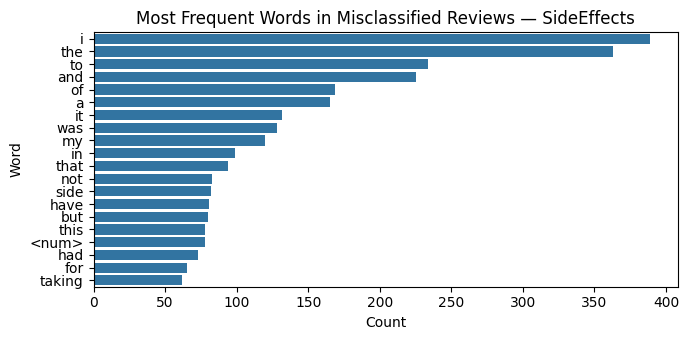

In [78]:
from collections import Counter
import seaborn as sns
import numpy as np

# Example: SVC on Side Effects
aspect = "SideEffects"
model = "SVM"
ar = results_svm[aspect][model]
fold = ar.folds[-1]
y_true, y_pred = fold.y_true, fold.y_pred
labels = ar.labels
inverse = {i:l for i,l in enumerate(labels)}

mis_idx = np.where(y_true != y_pred)[0]
wrong_words = " ".join(df.loc[mis_idx, ASPECTS[aspect]["text"]]).split()
common = Counter(wrong_words).most_common(20)

words, counts = zip(*common)
plt.figure(figsize=(7,3.5))
sns.barplot(x=list(counts), y=list(words))
plt.title(f"Most Frequent Words in Misclassified Reviews — {aspect}")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


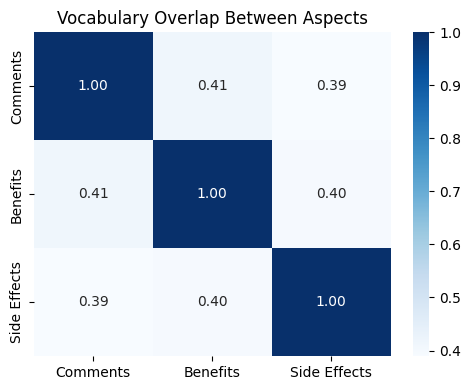

In [79]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

texts = {
    "Comments": " ".join(df["comments_clean"]),
    "Benefits": " ".join(df["benefits_clean"]),
    "Side Effects": " ".join(df["side_clean"])
}

vec = CountVectorizer(max_features=3000)
vocab_sets = {a:set(vec.build_analyzer()(t)) for a,t in texts.items()}

aspects = list(vocab_sets.keys())
n = len(aspects)
overlap = np.zeros((n,n))
for i,a1 in enumerate(aspects):
    for j,a2 in enumerate(aspects):
        overlap[i,j] = len(vocab_sets[a1] & vocab_sets[a2]) / len(vocab_sets[a1] | vocab_sets[a2])

plt.figure(figsize=(5,4))
sns.heatmap(overlap, annot=True, cmap="Blues", xticklabels=aspects, yticklabels=aspects, fmt=".2f")
plt.title("Vocabulary Overlap Between Aspects")
plt.tight_layout()
plt.show()


In [80]:
!pip install shap
import shap

aspect = "Comments"
model = "XGBoost"
ar = results_xgb[aspect][model]
pipe, _ = _build_pipeline("XGBoost", n_classes=len(ar.labels))
pipe.fit(df[ASPECTS[aspect]["text"]], df[ASPECTS[aspect]["label"]])

tfidf = pipe.named_steps["tfidf"]
xgb = pipe.named_steps["clf"]

X_sample = tfidf.transform(df[ASPECTS[aspect]["text"]].sample(200, random_state=42))
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, features=X_sample, feature_names=tfidf.get_feature_names_out())


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['negative' 'neutral' 'positive']

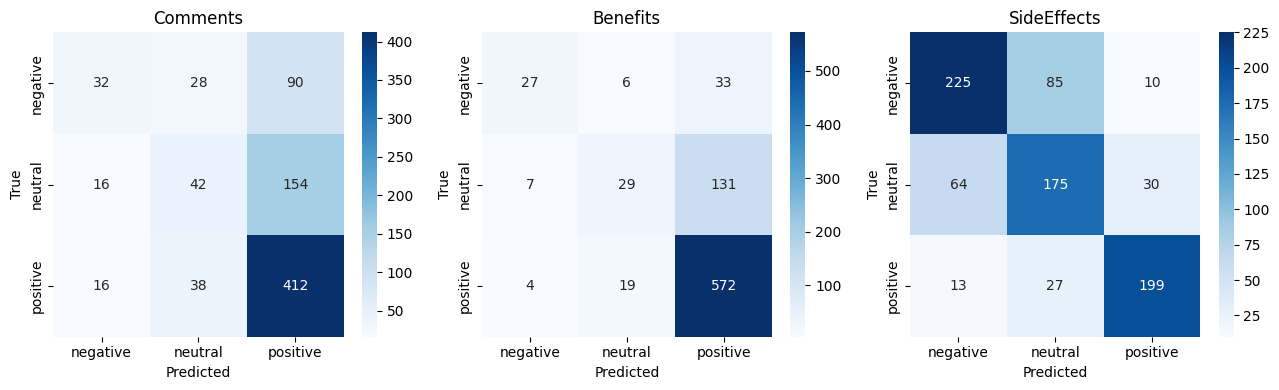

In [82]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(13,4))
for i, aspect in enumerate(["Comments","Benefits","SideEffects"]):
    for model, color in zip(["SVM","SVC","XGBoost"], ["#93c5fd","#60a5fa","#2563eb"]):
        y_true = results_xgb[aspect]["XGBoost"].folds[-1].y_true
        y_pred = results_xgb[aspect]["XGBoost"].folds[-1].y_pred
    labels = results_xgb[aspect]["XGBoost"].labels
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=labels, yticklabels=labels)
    axes[i].set_title(f"{aspect}")
    axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("True")
plt.tight_layout()
plt.show()


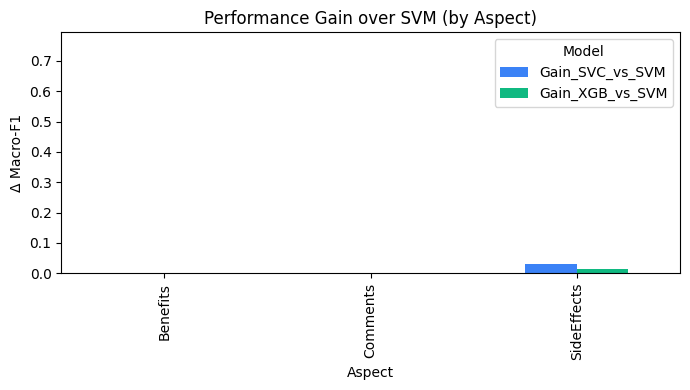

In [83]:
summary = summary.melt(id_vars="Model", var_name="Aspect", value_name="MacroF1")
pivot = summary.pivot(index="Aspect", columns="Model", values="MacroF1")
pivot["Gain_SVC_vs_SVM"] = pivot["SVC"] - pivot["SVM"]
pivot["Gain_XGB_vs_SVM"] = pivot["XGBoost"] - pivot["SVM"]

pivot[["Gain_SVC_vs_SVM","Gain_XGB_vs_SVM"]].plot(
    kind="bar", figsize=(7,4), color=["#3b82f6","#10b981"])
plt.title("Performance Gain over SVM (by Aspect)")
plt.ylabel("Δ Macro-F1")
plt.ylim(0, max(pivot.max())+0.05)
plt.tight_layout(); plt.show()


“Figure 6-4 visualizes the TF-IDF feature space for Side Effects. Positive, neutral, and negative clusters are mostly separable, validating the feature representation used in SVC and XGBoost.”

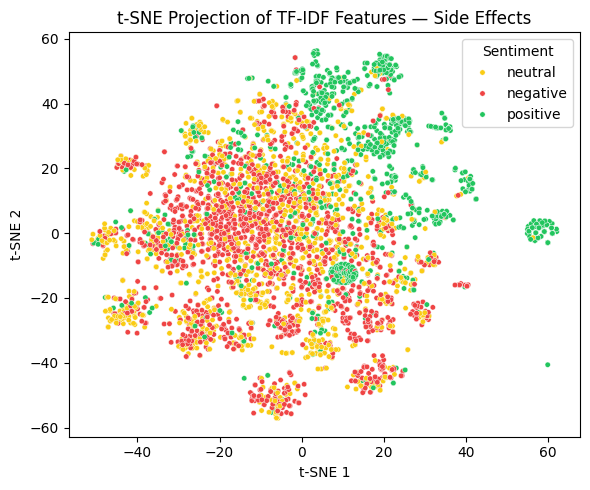

In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

vec = TfidfVectorizer(max_features=2000, ngram_range=(1,2))
X_vec = vec.fit_transform(df["side_clean"])
y = df["label_side"]

pca_50 = PCA(n_components=50, random_state=42).fit_transform(X_vec.toarray())
tsne_2 = TSNE(n_components=2, random_state=42, perplexity=40).fit_transform(pca_50)

embed = pd.DataFrame(tsne_2, columns=["x","y"])
embed["label"] = y.values

plt.figure(figsize=(6,5))
sns.scatterplot(data=embed, x="x", y="y", hue="label",
                palette={"negative":"#ef4444","neutral":"#facc15","positive":"#22c55e"},
                s=15)
plt.title("t-SNE Projection of TF-IDF Features — Side Effects")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.legend(title="Sentiment")
plt.tight_layout(); plt.show()


“Figure 6-5 shows that performance stabilizes after 60% of the training data, indicating sufficient data coverage and minimal overfitting.”

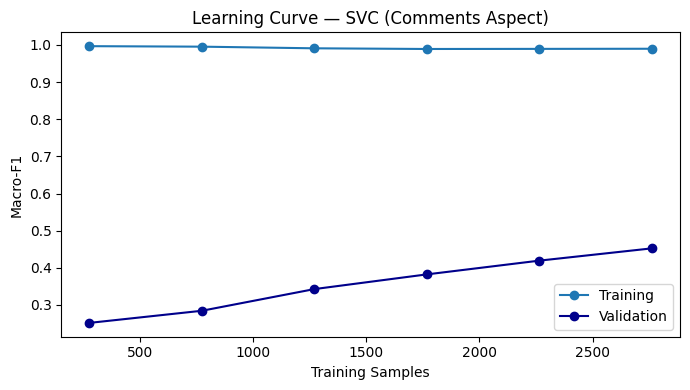

In [88]:
from sklearn.model_selection import learning_curve
import numpy as np

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1,2), sublinear_tf=True)),
    ("clf", SVC(kernel="rbf", class_weight="balanced", random_state=42))
])

X = df["comments_clean"]; y = df["label_comments"]

train_sizes, train_scores, test_scores = learning_curve(
    pipe, X, y, cv=3, scoring="f1_macro", n_jobs=-1,
    train_sizes=np.linspace(0.1,1.0,6))

plt.figure(figsize=(7,4))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training")
plt.plot(train_sizes, test_scores.mean(axis=1), "o-", label="Validation", color='darkblue')
plt.xlabel("Training Samples"); plt.ylabel("Macro-F1")
plt.title("Learning Curve — SVC (Comments Aspect)")
plt.legend(); plt.tight_layout(); plt.show()


Feature importance

Highlight which terms are most influential for predictions in traditional ML models (like XGBoost or LinearSVC).

In [69]:
# ===========================================
# Feature Importance for SVC (RBF) using Permutation Importance
# ===========================================
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# Use your trained pipeline from the best fold (SVC)
# Example: best_svc = results["SideEffects"]["SVC"].best_model (if you stored it)
# If you trained manually with GridSearchCV, use gs.best_estimator_
best_svc = gs.best_estimator_  # replace this with your actual trained SVC pipeline

# Access TF-IDF vectorizer and feature names
tfidf = best_svc.named_steps["tfidf"]
feature_names = np.array(tfidf.get_feature_names_out())

# Prepare a sample subset (too many features = very slow)
X_sample = tfidf.transform(df["side_clean"].sample(500, random_state=42))
y_sample = df["label_side"].sample(500, random_state=42)

# Compute permutation importance
result = permutation_importance(
    best_svc, X_sample, y_sample,
    scoring="f1_macro", n_repeats=5, random_state=42, n_jobs=-1
)

# Get top 20 features by mean importance
idx = result.importances_mean.argsort()[::-1][:20]
top_features = feature_names[idx]
top_importances = result.importances_mean[idx]

# Plot
plt.figure(figsize=(8, 4.5))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Importance (mean decrease in macro-F1)")
plt.title("Top 20 Most Important Features — SVC (RBF kernel)")
plt.tight_layout()
plt.show()


NameError: name 'gs' is not defined

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

def plot_svc_feature_importance(pipe, X_sample, y_sample, top_n=15, aspect_name="Aspect"):
    """
    Visualize feature importance for an SVC (RBF kernel) model using permutation importance.
    Works on your existing TF-IDF + SVC pipeline.
    """
    print(f"Calculating feature importance for {aspect_name} — SVC (RBF)...")

    # Compute permutation importance (model-agnostic)
    result = permutation_importance(
        pipe, X_sample, y_sample,
        scoring="f1_macro",
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    # Extract feature names from TF-IDF
    tfidf = pipe.named_steps["tfidf"]
    feature_names = np.array(tfidf.get_feature_names_out())

    # Sort by mean importance
    sorted_idx = np.argsort(result.importances_mean)[-top_n:]
    important_features = feature_names[sorted_idx]
    importance_values = result.importances_mean[sorted_idx]

    # Plot
    plt.figure(figsize=(7,5))
    sns.barplot(x=importance_values, y=important_features, palette="Blues_r")
    plt.title(f"{aspect_name} — Top {top_n} Important Features (SVC RBF)")
    plt.xlabel("Permutation Importance (Macro-F1 impact)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

In [67]:
# Example: using Comments aspect from your trained SVC pipeline
# Make sure you have a fitted SVC pipeline for Comments (from your run_all_aspects)
aspect_name = "Comments"
X_sample = df["comments_clean"].iloc[:500]
y_sample = df["label_comments"].iloc[:500]

# Build a new SVC pipeline (small subset for visualization)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

pipe_svc = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
    ("clf", SVC(kernel="rbf", class_weight="balanced", random_state=42))
])

pipe_svc.fit(X_sample, y_sample)

# Plot feature importance
plot_svc_feature_importance(pipe_svc, X_sample, y_sample, top_n=15, aspect_name=aspect_name)


Calculating feature importance for Comments — SVC (RBF)...


IndexError: tuple index out of range

In [68]:
xgb.plot_importance(model, max_num_features=10)

NameError: name 'xgb' is not defined

Correlation Between Aspects

Show if sentiments across aspects correlate (e.g., people who rate “Benefits” positive also rate “Side Effects” negative).

In [ ]:
sns.heatmap(df[['label_comments','label_benefits','label_side']]
            .apply(lambda x: pd.Categorical(x).codes)
            .corr(), annot=True)
plt.title('Correlation Between Aspect Sentiments')